In [1]:
import numpy as np
from matplotlib import pyplot as plt

import data
import output
import video

VOLUMES_DIR = output.get_dir("volumes")
SEG_PLOTS_DIR = output.get_dir("seg_plots")

In [2]:
echo_times = data.get_echo_times()
print(echo_times)

ids = data.get_ids()
print(ids)

[13.0, 16.0, 20.0, 25.0, 30.0, 40.0, 50.0, 85.0, 100.0, 150.0]
[11610, 13267, 13620, 14121, 14416, 15516, 15757, 16926, 17065, 18966, 21302, 21511, 22313, 22598, 23128, 23140, 24217, 24300, 25316, 25985, 26132, 27155, 28717, 28999, 30002, 30142, 30750, 31084, 32437, 33936, 34160, 35162, 35837, 35893, 36152, 36395, 36559, 36577, 36937, 37648, 37808, 38475, 38479, 39341, 39887, 40818, 42259, 42959, 43105, 43203, 43607, 44254, 44631, 45148, 45195, 45442, 45858, 46431, 46558, 46831, 47318, 47476, 47719, 47931, 48142, 48536, 48775, 48996, 49479, 49589, 49706, 50493, 50523, 50846, 51795, 52422, 52653, 53459, 55894, 56643, 58846, 59011, 60112, 60962, 62078, 62943, 63959, 65088, 65750, 65751, 66036, 66302, 66610, 66734, 67358, 67504, 68990, 69131, 69241, 70915, 71479, 71935, 71981, 72993, 74067, 74131, 74343, 76780, 76797, 78004, 78130, 78978, 79717, 79815, 80621, 80643, 80743, 81324, 81555, 81926, 82329, 82343, 82845, 83677, 83747, 85253, 85411, 85904, 85981, 88031, 88335, 91922, 92050, 92267

### 1. Visualizing the Segmentation Maps

In [3]:
# Inspect a dataset for a given ID
subject_id = data.get_ids()[0]
dataset = data.load_dataset(subject_id)

print(f"ID: {dataset.id}")
print(f"reg shape: {np.array(dataset.reg).shape}")   # (x, y, z, time)
print(f"seg shape: {np.array(dataset.seg).shape}")   # (x, y, z, segments)
print(f"mask shape: {np.array(dataset.mask).shape}")  # (x, y, z)

ID: 11610
reg shape: (96, 96, 51, 10)
seg shape: (96, 96, 51, 6)
mask shape: (96, 96, 51)


/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/3863636922.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(f"reg shape: {np.array(dataset.reg).shape}")   # (x, y, z, time)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/3863636922.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(f"seg shape: {np.array(dataset.seg).shape}")   # (x, y, z, segments)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/3863636922.

/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/3394025316.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reg = np.array(dataset.reg)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/3394025316.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


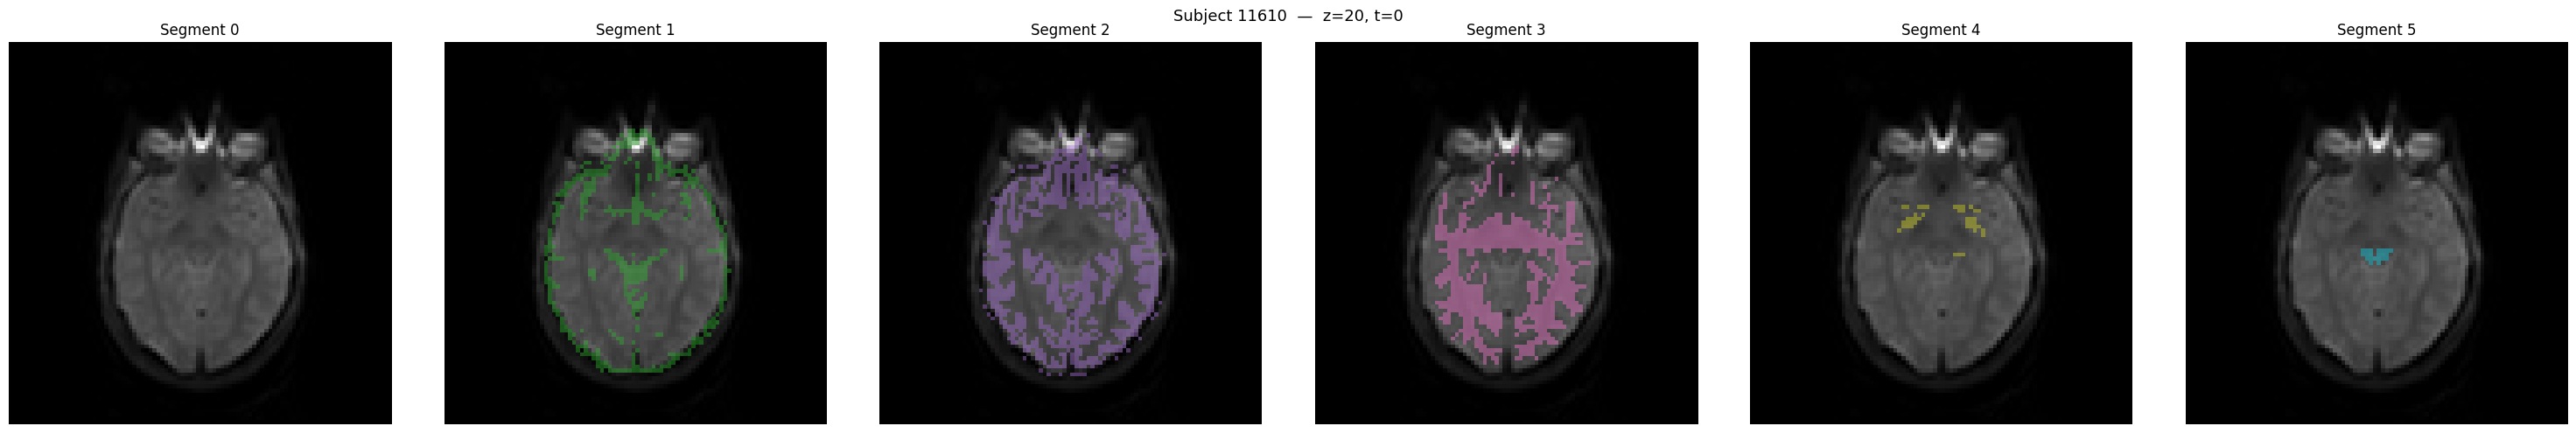

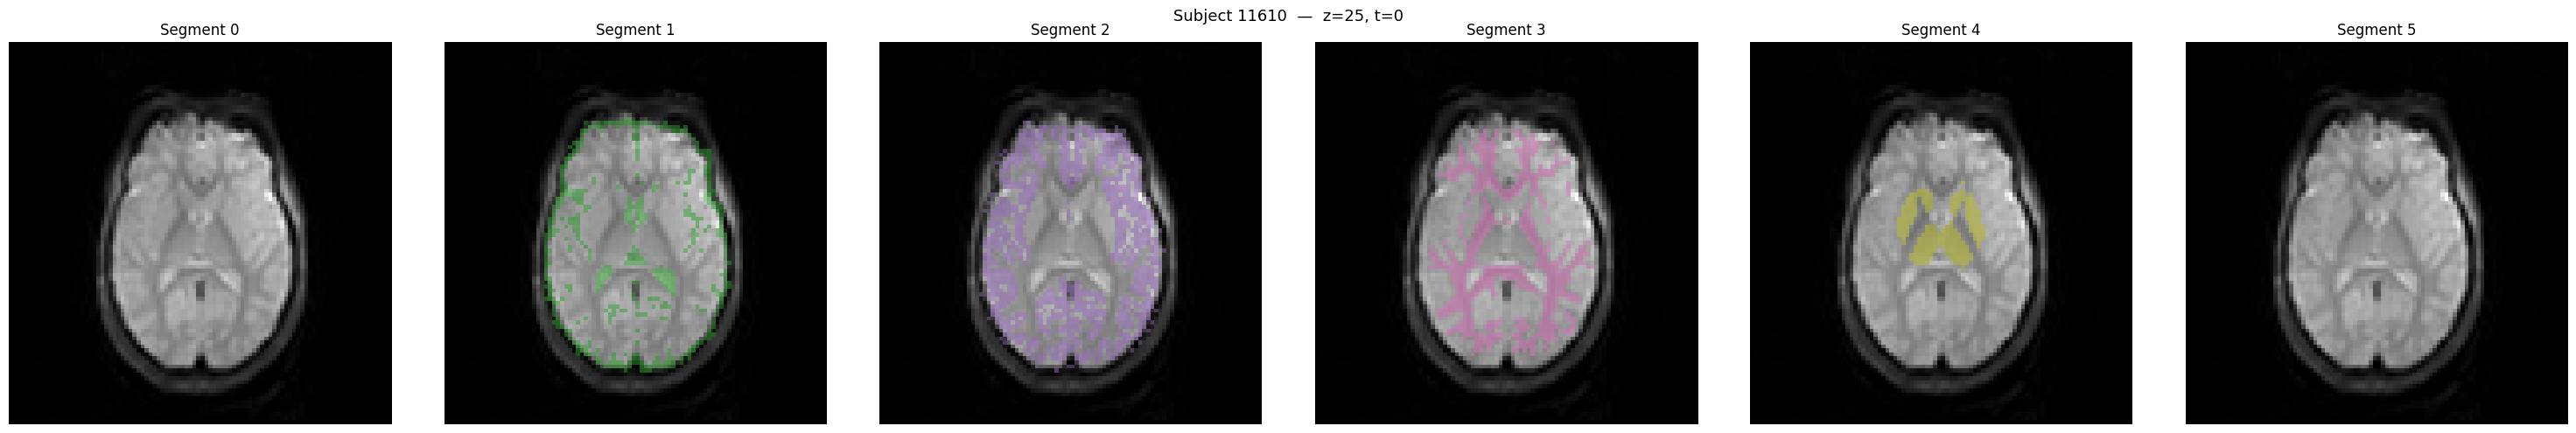

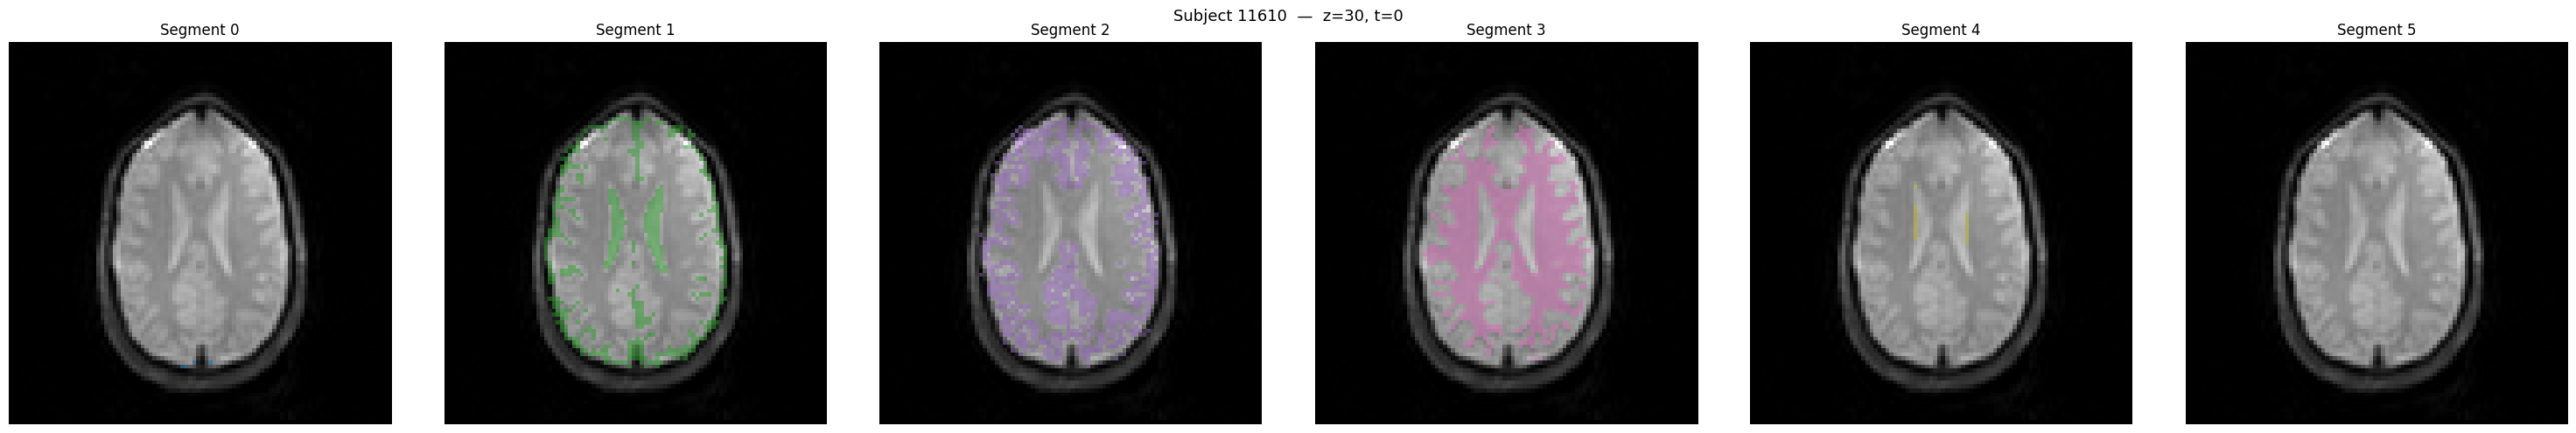

In [4]:
def show_seg_overlay(id, z_slice=25, time_step=0, alpha=0.5):
    """Overlay each segment's spatial footprint on a brain slice for the given subject id."""
    dataset = data.load_dataset(id)
    reg = np.array(dataset.reg)
    seg = np.array(dataset.seg)

    brain = reg[:, :, z_slice, time_step]
    seg_slice = seg[:, :, z_slice, :]   # (x, y, n_segments)
    n_segments = seg_slice.shape[-1]

    label_map = np.argmax(seg_slice, axis=-1).astype(float)   # (x, y), values 0..n_segments-1
    any_seg = seg_slice.max(axis=-1) > 0

    fig, axes = plt.subplots(1, n_segments, figsize=(5 * n_segments, 5))
    if n_segments == 1:
        axes = [axes]

    for seg_id in range(n_segments):
        ax = axes[seg_id]
        # Show the label_map value only where this segment dominates
        masked = np.ma.masked_where(~(any_seg & (label_map == seg_id)), label_map)

        ax.imshow(brain.T, origin="lower", cmap="gray")
        ax.imshow(masked.T, origin="lower", cmap="tab10",
                  vmin=0, vmax=n_segments - 1, alpha=alpha)
        ax.set_title(f"Segment {seg_id}")
        ax.axis("off")

    fig.suptitle(f"Subject {id}  —  z={z_slice}, t={time_step}", fontsize=13)
    plt.tight_layout()
    plt.show()

# Show for a few axial slices
for z in [20, 25, 30]:
    show_seg_overlay(subject_id, z_slice=z)

In [5]:
from matplotlib.animation import ArtistAnimation

def make_seg_sweep_z(id, time_step=0, alpha=0.5):
    """Per segment: video sweeping through z-slices at a fixed echo time."""
    dataset = data.load_dataset(id)
    reg = np.array(dataset.reg)
    seg = np.array(dataset.seg)
    n_z = reg.shape[2]
    n_segments = seg.shape[-1]
    out_dir = output.get_dir(id)

    for seg_id in range(n_segments):
        fig, ax = plt.subplots(figsize=(6, 6))
        fig.suptitle(f"Subject {id} — Segment {seg_id} (sweep z)")
        ax.axis("off")

        artists = []
        for z in range(n_z):
            brain = reg[:, :, z, time_step]
            seg_slice = seg[:, :, z, :]
            label_map = np.argmax(seg_slice, axis=-1).astype(float)
            any_seg = seg_slice.max(axis=-1) > 0
            masked = np.ma.masked_where(~(any_seg & (label_map == seg_id)), label_map)

            im_brain = ax.imshow(brain.T, origin="lower", cmap="gray", animated=True)
            im_seg = ax.imshow(masked.T, origin="lower", cmap="tab10",
                               vmin=0, vmax=n_segments - 1, alpha=alpha, animated=True)
            title = ax.text(0.5, 1.01, f"z = {z}", transform=ax.transAxes,
                            ha="center", va="bottom", fontsize=11)
            artists.append([im_brain, im_seg, title])

        anim = ArtistAnimation(fig, artists, interval=200)
        path = out_dir / f"seg_{seg_id}_sweep_z.mp4"
        anim.save(str(path), writer="ffmpeg")
        print(f"Saved: {path}")
        plt.close(fig)

make_seg_sweep_z(subject_id)

/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/3333362050.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reg = np.array(dataset.reg)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/3333362050.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_0_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_1_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_2_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_3_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_4_sweep_z.mp4
Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/seg_5_sweep_z.mp4


In [6]:
def make_seg_sweep_echo(id, z_slice=25, alpha=0.5):
    """All segments on one slice: video sweeping through echo times to see if segmentation changes."""
    dataset = data.load_dataset(id)
    reg = np.array(dataset.reg)
    seg = np.array(dataset.seg)
    n_time = reg.shape[3]
    n_segments = seg.shape[-1]
    echo_times = data.get_echo_times()
    out_dir = output.get_dir(id)

    fig, axes = plt.subplots(1, n_segments, figsize=(5 * n_segments, 5))
    if n_segments == 1:
        axes = [axes]
    for ax in axes:
        ax.axis("off")

    artists = []
    for t in range(n_time):
        brain = reg[:, :, z_slice, t]
        seg_slice = seg[:, :, z_slice, :]
        label_map = np.argmax(seg_slice, axis=-1).astype(float)
        any_seg = seg_slice.max(axis=-1) > 0

        frame = []
        for seg_id, ax in enumerate(axes):
            masked = np.ma.masked_where(~(any_seg & (label_map == seg_id)), label_map)
            im_brain = ax.imshow(brain.T, origin="lower", cmap="gray", animated=True)
            im_seg = ax.imshow(masked.T, origin="lower", cmap="tab10",
                               vmin=0, vmax=n_segments - 1, alpha=alpha, animated=True)
            frame.extend([im_brain, im_seg])

        te_label = f"TE = {echo_times[t]:.1f} ms" if t < len(echo_times) else f"t = {t}"
        title = fig.text(0.5, 0.98, te_label, ha="center", va="top", fontsize=12,
                         transform=fig.transFigure)
        frame.append(title)
        artists.append(frame)

    fig.suptitle(f"Subject {id} — z={z_slice}  (sweep echo times)", fontsize=14, y=1.03)
    anim = ArtistAnimation(fig, artists, interval=500)
    path = out_dir / f"all_segs_z{z_slice}_sweep_echo.mp4"
    anim.save(str(path), writer="ffmpeg")
    print(f"Saved: {path}")
    plt.close(fig)

make_seg_sweep_echo(subject_id, z_slice=25)

/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/1127256434.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reg = np.array(dataset.reg)
/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_46140/1127256434.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


Saved: /Users/puripatwongpadungkiet/cw2_comp0118/python/output/11610/all_segs_z25_sweep_echo.mp4


In [23]:
# Print unique values in the segmentation maps
dataset = data.load_dataset(subject_id)
seg = np.array(dataset.seg)
n_segments = seg.shape[-1]
for seg_id in range(n_segments):
    unique_values = np.unique(seg[:, :, :, seg_id])
    print(f"Segment {seg_id}: unique values = {unique_values}")

Segment 0: unique values = [-0.07953001 -0.06595595 -0.03740401 ...  0.17542662  0.2169957
  0.26997   ]
Segment 1: unique values = [-0.22011767 -0.2028593  -0.19146438 ...  1.2008789   1.2042615
  1.2069998 ]
Segment 2: unique values = [-0.19540201 -0.1887539  -0.18634933 ...  1.1796191   1.2004024
  1.2248946 ]
Segment 3: unique values = [-0.22489783 -0.200402   -0.17957933 ...  1.18632     1.1887543
  1.196424  ]
Segment 4: unique values = [-0.12047339 -0.09843944 -0.09790366 ...  1.1041688   1.1179874
  1.1301277 ]
Segment 5: unique values = [-0.1403443  -0.12485512 -0.10903209 ...  1.0993434   1.1026407
  1.1213044 ]


/var/folders/4t/yyv2xt5d5711qlypt6w9j0c40000gn/T/ipykernel_23047/735047176.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  seg = np.array(dataset.seg)


### 2. Plotting the Time-Intensity Curves of Individual Voxels

[4363.0392811  3909.38661122 3699.29788748 3455.72613634 3203.01065578
 2822.43330223 2431.69143831 1384.18927807 1106.39014525  491.05366195]
[ -453.65266989  -210.08872374  -243.57175114  -252.71548056
  -380.57735355  -390.74186392 -1047.50216025  -277.79913282
  -615.3364833 ]


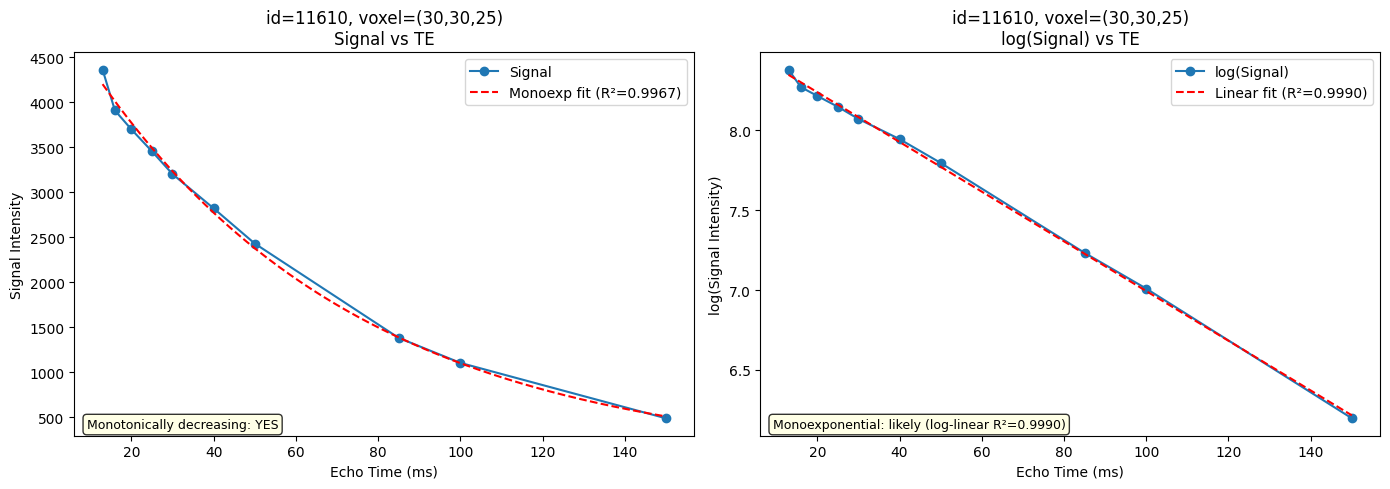

In [ ]:
from scipy.optimize import curve_fit

def monoexp(t, S0, R2):
    return S0 * np.exp(-t * R2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

def plot_single_voxel_decay(dataset, x, y, z, echo_times=None, save_path=None):
    """
    Investigates the signal decay of a single voxel across echo times.

    Plots:
      1. S(TE) vs. TE
      2. ln(S(TE)) vs TE
      3. Exponential decay fit overlaid on the raw signal

    Annotates whether the decay is monotonic and how well a
    monoexponential model fits (via R²).
    """
    if echo_times is None:
        echo_times = data.get_echo_times()

    signal = np.array(dataset.reg[x, y, z, :], dtype=float)
    te = np.array(echo_times[: len(signal)])

    # Check monotonicity and count increasing steps
    diffs = np.diff(signal)
    print(signal)
    print(diffs)
    is_monotonic = np.all(diffs <= 0)
    n_increasing = int(np.sum(diffs > 0))

    # Perform log-domain linear fit which corresponds to monoexponential decay in original domain (1)
    positive_mask = signal > 0
    te_pos = te[positive_mask]
    log_signal = np.log(signal[positive_mask])

    if len(te_pos) >= 2:
        coeffs = np.polyfit(te_pos, log_signal, 1)  # slope, intercept
        log_fit = np.polyval(coeffs, te_pos)
        r2_log = r2_score(log_signal, log_fit)
    else:
        coeffs = None
        r2_log = float("nan")

    # Fit monoexponential decay in original domain to get fitted curve and R² (2)
    try:
        p0 = [signal[0], -coeffs[0]] if coeffs is not None else [signal[0], 0.01]
        popt, _ = curve_fit(monoexp, te, signal, p0=p0, maxfev=10000)
        fitted_curve = monoexp(te, *popt)
        r2_fit = r2_score(signal, fitted_curve)
    except RuntimeError:
        popt = None
        fitted_curve = None
        r2_fit = float("nan")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title = f"id={dataset.id}, voxel=({x},{y},{z})"

    # 1. S(TE) vs. TE (with monoexponential fit)
    ax = axes[0]
    ax.plot(te, signal, "o-", label="Signal")
    if fitted_curve is not None:
        te_smooth = np.linspace(te[0], te[-1], 200)
        ax.plot(
            te_smooth,
            monoexp(te_smooth, *popt),
            "--",
            color="red",
            label=f"Monoexp fit (R²={r2_fit:.4f})",
        )
    ax.set_xlabel("Echo Time (ms)")
    ax.set_ylabel("Signal Intensity")
    ax.set_title(f"{title}\nSignal vs TE")
    ax.legend()

    # Annotate monotonicity
    mono_text = "Monotonically decreasing: YES" if is_monotonic else (
        f"Monotonically decreasing: NO ({n_increasing} increasing step(s))"
    )
    ax.annotate(
        mono_text,
        xy=(0.02, 0.02),
        xycoords="axes fraction",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8),
    )

    # 2. ln(S(TE)) vs TE (with linear fit)
    ax = axes[1]
    ax.plot(te_pos, log_signal, "o-", label="log(Signal)")
    if coeffs is not None:
        te_smooth = np.linspace(te_pos[0], te_pos[-1], 200)
        ax.plot(
            te_smooth,
            np.polyval(coeffs, te_smooth),
            "--",
            color="red",
            label=f"Linear fit (R²={r2_log:.4f})",
        )
    ax.set_xlabel("Echo Time (ms)")
    ax.set_ylabel("log(Signal Intensity)")
    ax.set_title(f"{title}\nlog(Signal) vs TE")
    ax.legend()

    # Annotate monoexponential fit quality based on log-domain R²
    monoexp_text = (
        f"Monoexponential: {'likely' if r2_log > 0.99 else 'unlikely'} "
        f"(log-linear R²={r2_log:.4f})"
    )
    ax.annotate(
        monoexp_text,
        xy=(0.02, 0.02),
        xycoords="axes fraction",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8),
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig

dataset = data.load_dataset(subject_id)
fig = plot_single_voxel_decay(dataset, x=30, y=30, z=25, echo_times=echo_times)
plt.show()

### 3. Plotting the Time-Intensity Curves of Regions of Interest (ROIs)